In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

!pip show equinox || echo equinox not found. Installing && pip install equinox 2> /dev/null

Name: equinox
Version: 0.11.11
Summary: Elegant easy-to-use neural networks in JAX.
Home-page: 
Author: 
Author-email: Patrick Kidger <contact@kidger.site>
License: Apache License
                           Version 2.0, January 2004
                        http://www.apache.org/licenses/

   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION

   1. Definitions.

      "License" shall mean the terms and conditions for use, reproduction,
      and distribution as defined by Sections 1 through 9 of this document.

      "Licensor" shall mean the copyright owner or entity authorized by
      the copyright owner that is granting the License.

      "Legal Entity" shall mean the union of the acting entity and all
      other entities that control, are controlled by, or are under common
      control with that entity. For the purposes of this definition,
      "control" means (i) the power, direct or indirect, to cause the
      direction or management of such entity, whether by con

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Spectral Bias of Neural Networks


{cite:t}`rahaman2019spectral` showed that neural networks are biased toward low-frequency components of the input signal. This behavior is known as spectral bias.
This problem inhibits the ability to train PINNs for high frequency problems, e.g., problems exhibiting localized features like shocks, boundary layers, etc.
The problem of spectral bias can be understood theoretically using the neural tangent kernel (NTK), which describes how small parameter updates near initialization change the network's predictions.
We will demonstrate this bias using a simple example.
We will train a simple MLP to approximate a function with a low frequency and a high frequency component.
We will check how the MLP does after each epoch.
You should notice that the MLP is biased towards the low frequency component of the function.
Only after a large number of epochs, the MLP starts to capture the high frequency component of the function.

## Numerical Example

The function we will use is given by

$$
f(x) = \sin(2\pi x) + 0.5\sin(16\pi x),
$$

for $x \in [0, 1]$.

Let's visualize it and the data we will use for training the neural network.



array([<Axes: xlabel='$x$', ylabel='$f(x)$'>], dtype=object)

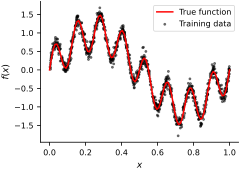

In [3]:
import numpy as np
import jax.numpy as jnp

f = lambda x: jnp.sin(2.0 * jnp.pi * x) + 0.5 * jnp.sin(16.0 * jnp.pi * x)

num_train = 1_000
x_train = np.random.rand(num_train)
y_train = f(x_train) + np.random.randn(num_train) * 0.1

fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
x = jnp.linspace(0, 1, 100)
ax.plot(x, f(x), 'r-', label='True function')
ax.scatter(x_train, y_train, s=4, c='black', alpha=0.5, label='Training data')
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.legend(loc='best', frameon=True)
finalize_axes(keep_box=False)

The following code trains a generic neural network on the data.
It returns the trained model after each epoch.

In [4]:
import equinox as eqx
import optax

    
def data_generator(X, y, batch_size, shuffle=True):
    num_samples = X.shape[0]
    indices = np.arange(num_samples)
    if shuffle:
        np.random.shuffle(indices)
    
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], y[batch_indices]

def loss(model, x, y):
    y_pred = model(x).flatten()
    return optax.l2_loss(y_pred, y).mean()

def train_batch(
        model,
        x, y,
        optimizer,
        n_batch=10,
        n_epochs=10,
        freq=1_000,
    ):

    # This is the step of the optimizer. We **always** jit:
    @eqx.filter_jit
    def step(opt_state, model, xi, yi):
        value, grads = eqx.filter_value_and_grad(loss)(model, xi, yi)
        updates, opt_state = optimizer.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, value
    
    # The state of the optimizer
    opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))
    # The path of the model
    path = []
    # The path of the test loss
    losses = []
    for e in range(n_epochs):
        for i, (xb, yb) in enumerate(data_generator(x, y, n_batch)):
            model, opt_state, value = step(opt_state, model, xb[:, None], yb)
            if i % freq == 0:
                path.append(model)
                losses.append(value)
                print(f"Epoch {e}, step {i}, loss {value:.3f}, test {losses[-1]:.3f}")
    return model, path, losses

Let's also write some code to visualize the predictions of the model after each epoch.

In [5]:
def plot(model, x_train, y_train, f_true, style='b--'):
    x = jnp.linspace(0, 1, 100)[:, None]
    fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
    ax.plot(x, f_true(x), 'r-', label='True function')
    ax.scatter(x_train, y_train, s=4, c='black', alpha=0.5, label='Training data')
    ax.plot(x, model(x), style, label='Model')
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$f(x)$")
    ax.legend(loc='best')
    finalize_axes(keep_box=False)
    return fig, ax


We will try this on a simple MLP:

In [6]:
import jax.random as jrandom

key = jrandom.PRNGKey(0)
subkey, key = jrandom.split(key)

width_size = 128
depth = 4
mlp = eqx.filter_vmap(
    eqx.nn.MLP(1, 1, width_size, depth, jnp.tanh, key=subkey))

optimizer = optax.adam(1e-3)
model, path, losses = train_batch(
    mlp, x_train, y_train, optimizer,
    n_batch=32, 
    n_epochs=300,
    freq=1_000
)

Epoch 0, step 0, loss 0.272, test 0.272


Epoch 1, step 0, loss 0.097, test 0.097
Epoch 2, step 0, loss 0.156, test 0.156
Epoch 3, step 0, loss 0.086, test 0.086
Epoch 4, step 0, loss 0.055, test 0.055
Epoch 5, step 0, loss 0.077, test 0.077
Epoch 6, step 0, loss 0.084, test 0.084
Epoch 7, step 0, loss 0.089, test 0.089
Epoch 8, step 0, loss 0.077, test 0.077
Epoch 9, step 0, loss 0.096, test 0.096


Epoch 10, step 0, loss 0.050, test 0.050
Epoch 11, step 0, loss 0.056, test 0.056
Epoch 12, step 0, loss 0.064, test 0.064
Epoch 13, step 0, loss 0.100, test 0.100
Epoch 14, step 0, loss 0.083, test 0.083
Epoch 15, step 0, loss 0.070, test 0.070
Epoch 16, step 0, loss 0.085, test 0.085
Epoch 17, step 0, loss 0.068, test 0.068
Epoch 18, step 0, loss 0.061, test 0.061


Epoch 19, step 0, loss 0.069, test 0.069
Epoch 20, step 0, loss 0.046, test 0.046
Epoch 21, step 0, loss 0.079, test 0.079
Epoch 22, step 0, loss 0.059, test 0.059
Epoch 23, step 0, loss 0.064, test 0.064
Epoch 24, step 0, loss 0.080, test 0.080
Epoch 25, step 0, loss 0.059, test 0.059
Epoch 26, step 0, loss 0.065, test 0.065


Epoch 27, step 0, loss 0.043, test 0.043
Epoch 28, step 0, loss 0.089, test 0.089
Epoch 29, step 0, loss 0.076, test 0.076
Epoch 30, step 0, loss 0.092, test 0.092
Epoch 31, step 0, loss 0.064, test 0.064
Epoch 32, step 0, loss 0.055, test 0.055
Epoch 33, step 0, loss 0.066, test 0.066
Epoch 34, step 0, loss 0.079, test 0.079
Epoch 35, step 0, loss 0.066, test 0.066


...

Epoch 260, step 0, loss 0.040, test 0.040
Epoch 261, step 0, loss 0.018, test 0.018
Epoch 262, step 0, loss 0.026, test 0.026
Epoch 263, step 0, loss 0.019, test 0.019
Epoch 264, step 0, loss 0.030, test 0.030
Epoch 265, step 0, loss 0.028, test 0.028
Epoch 266, step 0, loss 0.027, test 0.027
Epoch 267, step 0, loss 0.018, test 0.018
Epoch 268, step 0, loss 0.029, test 0.029


Epoch 269, step 0, loss 0.028, test 0.028
Epoch 270, step 0, loss 0.033, test 0.033
Epoch 271, step 0, loss 0.033, test 0.033
Epoch 272, step 0, loss 0.026, test 0.026
Epoch 273, step 0, loss 0.033, test 0.033
Epoch 274, step 0, loss 0.026, test 0.026
Epoch 275, step 0, loss 0.035, test 0.035
Epoch 276, step 0, loss 0.033, test 0.033
Epoch 277, step 0, loss 0.039, test 0.039


Epoch 278, step 0, loss 0.026, test 0.026
Epoch 279, step 0, loss 0.017, test 0.017
Epoch 280, step 0, loss 0.032, test 0.032
Epoch 281, step 0, loss 0.023, test 0.023
Epoch 282, step 0, loss 0.023, test 0.023
Epoch 283, step 0, loss 0.019, test 0.019
Epoch 284, step 0, loss 0.027, test 0.027
Epoch 285, step 0, loss 0.022, test 0.022
Epoch 286, step 0, loss 0.039, test 0.039
Epoch 287, step 0, loss 0.027, test 0.027


Epoch 288, step 0, loss 0.029, test 0.029
Epoch 289, step 0, loss 0.021, test 0.021
Epoch 290, step 0, loss 0.036, test 0.036
Epoch 291, step 0, loss 0.012, test 0.012
Epoch 292, step 0, loss 0.024, test 0.024
Epoch 293, step 0, loss 0.031, test 0.031
Epoch 294, step 0, loss 0.018, test 0.018
Epoch 295, step 0, loss 0.015, test 0.015
Epoch 296, step 0, loss 0.025, test 0.025
Epoch 297, step 0, loss 0.021, test 0.021


Epoch 298, step 0, loss 0.016, test 0.016
Epoch 299, step 0, loss 0.029, test 0.029


Now, let's plot the result after some of the epochs:

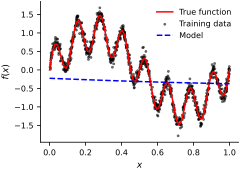

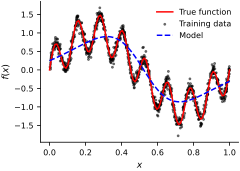

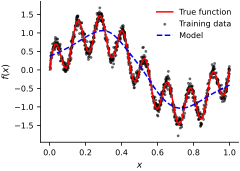

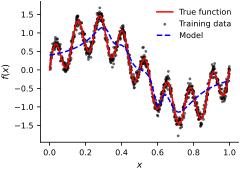

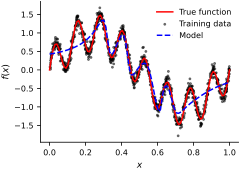

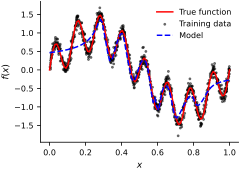

In [7]:
for e, model in enumerate(path[::50]):
    fig, ax = plot(model, x_train, y_train, f)

And you clearly observe the spectral bias problem.

## Random Fourier Features

One way to mitigate spectral bias is to use random Fourier features {cite:p}`tancik2020fourier`.
The idea is to map the input data to a higher dimensional space using random Fourier features.
The random Fourier features are designed to capture the high frequency components of the input signal.
These features go right before the input layer of the neural network.
Say our input data is $\mathbf{x} \in \mathbb{R}^d$ and that we want to map to a network with $m$-dimensional inputs.
Then, the random Fourier features are given by

$$
\boldsymbol{\phi}(\mathbf{x}) = 
\begin{bmatrix}
\cos(\mathbf{B}\mathbf{x}) \\
\sin(\mathbf{B}\mathbf{x})
\end{bmatrix},
$$

where $\mathbf{B}$ is a $m \times d$ matrix.
This matrix is constant throughout the training process.
But we typically pick it randomly from a Gaussian distribution.
Specifically, we pick each entry of $\mathbf{B}$ from a Gaussian distribution with mean 0 and variance $\sigma^2$.
For the PINN examples studied by {cite:t}`wang2021eigenvector`, values of $\sigma$ between $1$ and $10$ were effective. This range is a problem-dependent starting point rather than a universal rule.
The cosine and sine functions are applied element-wise.

## Applying Random Fourier Features to the Example

Let's implement random Fourier features and apply it to the previous example.

In [8]:
import jax
from functools import partial
import jax.tree_util as jtu


class FourierEncoding(eqx.Module):
    B: jax.Array

    @property
    def num_fourier_features(self) -> int:
        return self.B.shape[0]

    @property
    def in_size(self) -> int:
        return self.B.shape[1]
    
    @property
    def out_size(self) -> int:
        return self.B.shape[0] * 2

    def __init__(self, 
                 in_size: int, 
                 num_fourier_features: int, 
                 key: jax.random.PRNGKey, 
                 sigma: float = 1.0):
        self.B = jax.random.normal(
            key, shape=(num_fourier_features, in_size),
            dtype=jax.numpy.float32) * sigma
    
    def __call__(self, x: jax.Array) -> jax.Array:
        return jax.numpy.concatenate(
            [jax.numpy.cos(jax.numpy.dot(self.B, x)),
             jax.numpy.sin(jax.numpy.dot(self.B, x))],
            axis=0)

And here is how we can make the network.

In [9]:
num_fourier_features = 100
width_size = 128
depth = 4
sigma = 5.0

key1, key2, key = jax.random.split(key, 3)
fourier = FourierEncoding(1, num_fourier_features, key1, sigma)
mlp = eqx.nn.MLP(fourier.out_size, 1, width_size, depth, jax.numpy.tanh, key=key2)
fourier_mlp = eqx.filter_vmap(eqx.nn.Sequential([eqx.nn.Lambda(fourier), eqx.nn.Lambda(mlp)]))

Recall that we want to keep $\mathbf{B}$ constant throughout the training process.
We will have to modify our training algorithm to achieve this.
We will use `equinox.partition` capabilities to achieve this.

In [10]:
filter_spec = jtu.tree_map(lambda _: True, fourier_mlp)
filter_spec = eqx.tree_at(
    lambda tree: (tree._fun[0].fn.B,),
    filter_spec,
    replace=(False,),
)

In [11]:
def train_fourier(
        model,
        x, y,
        optimizer,
        filter_spec,
        n_batch=10,
        n_epochs=10,
        freq=1_000,
    ):

    # A new loss is also needed
    # It needs to combine the part of the model over
    # which we optimize with the part where we don't
    def new_loss(diff_model, static_model, x, y):
            comb_model = eqx.combine(diff_model, static_model)
            return loss(comb_model, x, y)

    # This is the step of the optimizer. We **always** jit:
    @eqx.filter_jit
    def step(opt_state, model, xi, yi):
        # The next two lines are also different
        # First we split the model into two parts
        diff_model, static_model = eqx.partition(model, filter_spec)
        # Then, we call the new loss
        value, grads = eqx.filter_value_and_grad(new_loss)(diff_model, static_model, xi, yi)
        updates, opt_state = optimizer.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, value
    
    # The state of the optimizer
    opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))
    # The path of the model
    path = []
    # The path of the test loss
    losses = []
    for e in range(n_epochs):
        for i, (xb, yb) in enumerate(data_generator(x, y, n_batch)):
            model, opt_state, value = step(opt_state, model, xb[:, None], yb)
            if i % freq == 0:
                path.append(model)
                losses.append(value)
                print(f"Epoch {e}, step {i}, loss {value:.3f}, test {losses[-1]:.3f}")
    return model, path, losses

Let's train it just for 100 epochs.

In [12]:
optimizer = optax.adam(1e-3)
trained_v_fourier_model, fourier_path, losses = train_fourier(
    fourier_mlp, x_train, y_train, optimizer,
    filter_spec,
    n_batch=32, 
    n_epochs=100,
    freq=1_000
)

Epoch 0, step 0, loss 0.425, test 0.425
Epoch 1, step 0, loss 0.078, test 0.078


Epoch 2, step 0, loss 0.076, test 0.076
Epoch 3, step 0, loss 0.089, test 0.089
Epoch 4, step 0, loss 0.062, test 0.062
Epoch 5, step 0, loss 0.105, test 0.105
Epoch 6, step 0, loss 0.064, test 0.064
Epoch 7, step 0, loss 0.056, test 0.056
Epoch 8, step 0, loss 0.051, test 0.051
Epoch 9, step 0, loss 0.070, test 0.070


Epoch 10, step 0, loss 0.057, test 0.057
Epoch 11, step 0, loss 0.070, test 0.070
Epoch 12, step 0, loss 0.057, test 0.057
Epoch 13, step 0, loss 0.045, test 0.045
Epoch 14, step 0, loss 0.056, test 0.056
Epoch 15, step 0, loss 0.060, test 0.060
Epoch 16, step 0, loss 0.054, test 0.054


Epoch 17, step 0, loss 0.067, test 0.067
Epoch 18, step 0, loss 0.059, test 0.059
Epoch 19, step 0, loss 0.053, test 0.053
Epoch 20, step 0, loss 0.043, test 0.043
Epoch 21, step 0, loss 0.043, test 0.043
Epoch 22, step 0, loss 0.055, test 0.055
Epoch 23, step 0, loss 0.043, test 0.043
Epoch 24, step 0, loss 0.033, test 0.033


Epoch 25, step 0, loss 0.029, test 0.029
Epoch 26, step 0, loss 0.021, test 0.021
Epoch 27, step 0, loss 0.023, test 0.023
Epoch 28, step 0, loss 0.016, test 0.016
Epoch 29, step 0, loss 0.016, test 0.016
Epoch 30, step 0, loss 0.009, test 0.009
Epoch 31, step 0, loss 0.009, test 0.009
Epoch 32, step 0, loss 0.012, test 0.012


...

Epoch 65, step 0, loss 0.006, test 0.006
Epoch 66, step 0, loss 0.007, test 0.007
Epoch 67, step 0, loss 0.005, test 0.005
Epoch 68, step 0, loss 0.005, test 0.005
Epoch 69, step 0, loss 0.008, test 0.008
Epoch 70, step 0, loss 0.006, test 0.006
Epoch 71, step 0, loss 0.009, test 0.009
Epoch 72, step 0, loss 0.010, test 0.010


Epoch 73, step 0, loss 0.007, test 0.007
Epoch 74, step 0, loss 0.006, test 0.006
Epoch 75, step 0, loss 0.007, test 0.007
Epoch 76, step 0, loss 0.007, test 0.007
Epoch 77, step 0, loss 0.007, test 0.007
Epoch 78, step 0, loss 0.006, test 0.006
Epoch 79, step 0, loss 0.006, test 0.006
Epoch 80, step 0, loss 0.009, test 0.009


Epoch 81, step 0, loss 0.004, test 0.004
Epoch 82, step 0, loss 0.004, test 0.004
Epoch 83, step 0, loss 0.009, test 0.009
Epoch 84, step 0, loss 0.006, test 0.006
Epoch 85, step 0, loss 0.006, test 0.006
Epoch 86, step 0, loss 0.007, test 0.007
Epoch 87, step 0, loss 0.007, test 0.007
Epoch 88, step 0, loss 0.008, test 0.008


Epoch 89, step 0, loss 0.006, test 0.006
Epoch 90, step 0, loss 0.004, test 0.004
Epoch 91, step 0, loss 0.007, test 0.007
Epoch 92, step 0, loss 0.006, test 0.006
Epoch 93, step 0, loss 0.007, test 0.007
Epoch 94, step 0, loss 0.010, test 0.010
Epoch 95, step 0, loss 0.010, test 0.010
Epoch 96, step 0, loss 0.007, test 0.007


Epoch 97, step 0, loss 0.010, test 0.010
Epoch 98, step 0, loss 0.004, test 0.004
Epoch 99, step 0, loss 0.008, test 0.008


Here are the results:

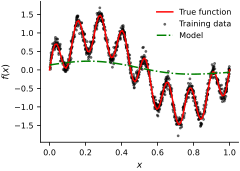

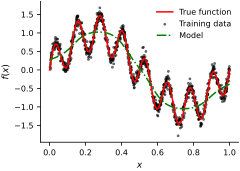

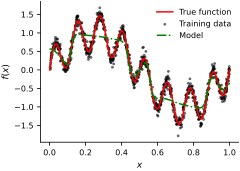

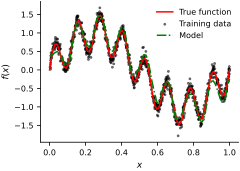

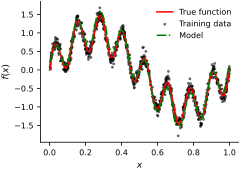

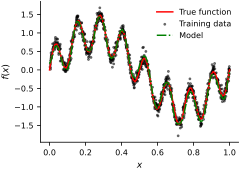

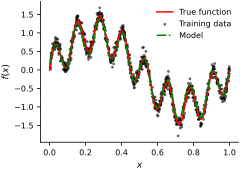

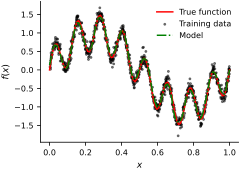

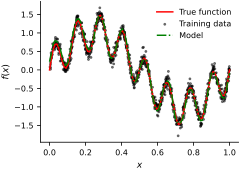

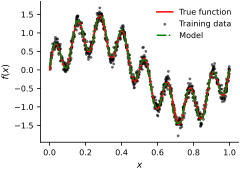

In [13]:
for e, model in enumerate(fourier_path[::10]):
    fig, ax = plot(model, x_train, y_train, f, style='g-.')

Notice that we learn the high-frequency component much faster than before.
Let's compare the two models side by side.

array([<Axes: xlabel='$x$', ylabel='$f(x)$'>], dtype=object)

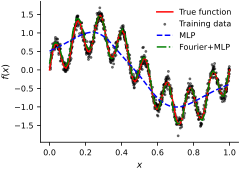

In [14]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
x = jnp.linspace(0, 1, 100)[:, None]
ax.plot(x, f(x), 'r-', label='True function')
ax.scatter(x_train, y_train, s=4, c='black', alpha=0.5, label='Training data')
ax.plot(x, path[99](x), 'b--', label='MLP')
ax.plot(x, fourier_path[99](x), 'g-.', label='Fourier+MLP')
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
plt.legend(loc='best', frameon=False);
finalize_axes(keep_box=False)

## PINNs with Random Fourier Features

Let's now see if we can do any better with PINNs on our steady-state heat equation example.

In [15]:
def train_pinn(
        loss,
        fourier_mlp,
        key,
        optimizer,
        filter_spec,
        Lx=1.0,
        Ly=1.0,
        num_collocation_residual=512,
        num_iter=10_000,
        freq=1,
    ):

    # this is new
    def new_loss(diff_model, static_model, x, y):
        comb_model = eqx.combine(diff_model, static_model)
        return loss(comb_model, x, y)

    @eqx.filter_jit
    def step(opt_state, model, xs, ys):
        # added this line
        diff_model, static_model = eqx.partition(model, filter_spec)
        # changed the loss to the new loss
        value, grads = eqx.filter_value_and_grad(new_loss)(diff_model, static_model, xs, ys)
        updates, opt_state = optimizer.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, value
    
    opt_state = optimizer.init(eqx.filter(fourier_mlp, eqx.is_inexact_array))
    
    losses = []
    for i in range(num_iter):
        key1, key2, key = jrandom.split(key, 3)
        xb = jrandom.uniform(key1, (num_collocation_residual,), maxval=Lx)
        yb = jrandom.uniform(key2, (num_collocation_residual,), maxval=Ly)
        fourier_mlp, opt_state, value = step(opt_state, fourier_mlp, xb, yb)
        if i % freq == 0:
            losses.append(value)
            print(f"Step {i}, residual loss {value:.3e}")
    return fourier_mlp, losses

Let's build everything to train the model.
Notice that we need to rescale.

In [16]:
from jax import grad, vmap

u0 = 500 # degrees Kelvin
k = 10.0 # thermal conductivity in W/mK
Lx = 0.1 # meters
Ly = 1.0 # meters

to_x = lambda xt: xt * Lx
to_y = lambda yt: yt * Ly
to_xt = lambda x: x / Lx
to_yt = lambda y: y / Ly

source_term = lambda x, y: 2.0 * jnp.pi ** 2 * k * u0 * (
    -Lx ** 2 * jnp.sin(jnp.pi * x / Lx) ** 2 * jnp.cos(2.0 * jnp.pi * y / Ly)
    -Ly ** 2 * jnp.sin(jnp.pi * y / Ly) ** 2 * jnp.cos(2.0 * jnp.pi * x / Lx)
) / (Lx ** 2 * Ly ** 2)

key1, key2, key = jax.random.split(key, 3)
num_fourier_features = 100
width_size = 128
depth = 4

model = eqx.nn.Sequential([
    eqx.nn.Lambda(
        FourierEncoding(2, num_fourier_features, key1, sigma=6.0)),
    eqx.nn.Lambda(
        eqx.nn.MLP(num_fourier_features * 2, 1, width_size, depth, jnp.tanh, key=key2)),
    eqx.nn.Lambda(
        lambda y: y[0])])
# remember that we need a way to filter out the parameters of the Fourier encoding
filter_spec = jtu.tree_map(lambda _: True, model)
filter_spec = eqx.tree_at(
    lambda tree: (tree[0].fn.B,),
    filter_spec,
    replace=(False,))

# The model that satisfies the boundary conditions
u_hat = lambda x, y, model: x * (1.0 - x) * y * (1.0 - y) * model(jnp.array([x, y]))
u_x = grad(u_hat, 0)
u_y = grad(u_hat, 1)
u_xx = grad(u_x, 0)
u_yy = grad(u_y, 1)

# We need to find new scaling factors because the network structure has changed
v_u_xx = eqx.filter_jit(eqx.filter_vmap(u_xx, in_axes=(0, 0, None)))
v_u_yy = eqx.filter_jit(eqx.filter_vmap(u_yy, in_axes=(0, 0, None)))
x = jnp.linspace(0, Lx, 100)
y = jnp.linspace(0, Ly, 100)
X, Y = jnp.meshgrid(x, y)
Xt = to_xt(X)
Yt = to_yt(Y)
max_u_xx = jnp.abs(v_u_xx(Xt.flatten(), Yt.flatten(), model)).max()
max_u_yy = jnp.abs(v_u_yy(Xt.flatten(), Yt.flatten(), model)).max()

# Calculate the scale:
fs = 9.96e+06
us = fs / k / max(max_u_xx, max_u_yy) / max(1/Lx**2, 1/Ly**2)
tkx = (k * us) / (Lx ** 2 * fs)
tky = (k * us) / (Ly ** 2 * fs)

print(f"Scale factor fs: {fs:.2e}")
print(f"Scale factor us: {us:.2e}")
print(f"tkx = {tkx:.3e}, tky = {tky:.3e}") 

tilde_source_term = lambda tx, ty: source_term(to_x(tx), to_y(ty)) / fs

pde_residual = vmap(
    lambda x, y, model: tkx * u_xx(x, y, model) + tky * u_yy(x, y, model) + tilde_source_term(x, y),
    in_axes=(0, 0, None))
pinn_loss = lambda model, x, y: jnp.mean(jnp.square(pde_residual(x, y, model)))

Scale factor fs: 9.96e+06
Scale factor us: 2.69e+04
tkx = 2.704e+00, tky = 2.704e-02


This is how we train:

In [17]:
key, subkey = jax.random.split(key)
optimizer = optax.adam(1e-3)
trained_model, losses = train_pinn(
    pinn_loss, model, key, optimizer, filter_spec,
    num_collocation_residual=256, num_iter=2_000, freq=100, Lx=1.0, Ly=1.0)

Step 0, residual loss 2.737e-01


Step 100, residual loss 1.276e-04


Step 200, residual loss 5.678e-05


Step 300, residual loss 2.237e-05


Step 400, residual loss 2.082e-05


...

Step 1500, residual loss 5.885e-06


Step 1600, residual loss 1.271e-05


Step 1700, residual loss 8.260e-06


Step 1800, residual loss 1.379e-04


Step 1900, residual loss 1.152e-05


Save the loss for later use:

In [18]:
import numpy as np
np.savez("fourier_mlp_losses.npz", losses=losses)

```{note}
Training time depends on the available hardware and includes the initial JAX compilation.
```

We now compare with the plain MLP.

array([<Axes: xlabel='Iterations x 100', ylabel='Loss'>], dtype=object)

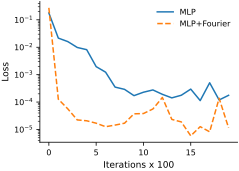

In [19]:
import numpy as np
mlp_losses = np.load("mlp_losses.npz")["losses"]
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(mlp_losses, label="MLP")
ax.plot(losses, '--', label="MLP+Fourier")
# set log scale for y axis
ax.set_yscale('log')
ax.set_xlabel("Iterations x 100")
ax.set_ylabel("Loss")
plt.legend(loc="best", frameon=False)
finalize_axes(keep_box=False)

Here is the solution we found compared to the exact solution:

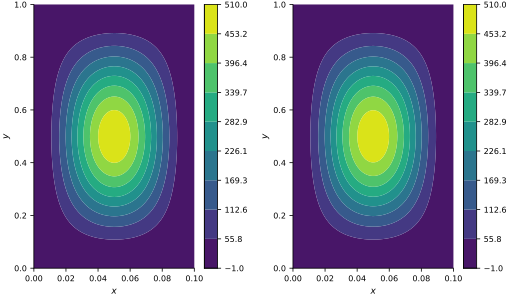

In [20]:
x = jnp.linspace(0, Lx, 100)
y = jnp.linspace(0, Ly, 100)
X, Y = jnp.meshgrid(x, y)
u_true = u0 * jnp.sin(jnp.pi * X / Lx) ** 2 * jnp.sin(jnp.pi * Y / Ly) ** 2

v_u_hat = vmap(u_hat, in_axes=(0, 0, None))
fig, ax = plt.subplots(1,2, figsize=FIGURE_SIZES["full_landscape"])
u_pred = v_u_hat(Xt.flatten(), Yt.flatten(), trained_model).reshape(X.shape)
c = ax[0].contourf(X, Y, u_pred * us, cmap='viridis',
    levels=jnp.linspace(-1, 510.0, 10))
fig.colorbar(c, ax=ax[0])
ax[0].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$y$')
finalize_axes(keep_box=True)
vsource_term = vmap(source_term, in_axes=(0, 0))
f = vsource_term(X.flatten(), Y.flatten()).reshape(X.shape)
c = ax[1].contourf(X, Y, u_true, cmap='viridis',
    levels=jnp.linspace(-1, 510.0, 10))
fig.colorbar(c, ax=ax[1])
ax[1].set_xlabel('$x$')
ax[1].set_ylabel('$y$')
sns.despine(trim=True)
plt.tight_layout();

And here is the error:

array([<Axes: xlabel='x', ylabel='y'>, <Axes: label='<colorbar>'>],
      dtype=object)

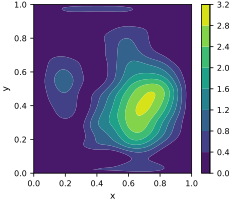

In [21]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_tall"])
ax.set_xlabel('x')
ax.set_ylabel('y')
c = ax.contourf(to_xt(X), to_yt(Y), jnp.abs(u_pred * us - u_true), cmap='viridis')
plt.colorbar(c, ax=ax)
finalize_axes(keep_box=True)